# Genome PRD v1 — 04 Model evaluation

Evaluate train, validation, and out-of-time test data with the established Phase 5/PRD definitions, including calibration, test-quarter metrics, and the same diagnostic plots used in the Phase 5 baseline notebook.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve
from xgboost import XGBClassifier

here = Path.cwd().resolve()
ROOT = next(path for path in (here, *here.parents) if (path / 'src/training/prd_config.py').is_file())
sys.path.insert(0, str(ROOT))
from src.training import prd_config
from src.training.modeling import evaluate_model, load_split, write_json

MAX_CURVE_ROWS = 2_000_000

model = XGBClassifier()
model.load_model(prd_config.PRD_ARTIFACT_PATH)
ratings = pd.read_parquet(prd_config.RATINGS_SOURCE_PATH, columns=['rating'])['rating'].to_numpy(dtype=np.float32, copy=False)

## Canonical split, calibration, and quarterly metrics

In [11]:
results = evaluate_model(
    model,
    prd_config.FEATURE_ARTIFACT_PATH,
    ratings,
    curve_sample_rows=MAX_CURVE_ROWS,
)
curve_samples = results.pop('curve_samples')
metric_table = pd.DataFrame(results['metrics']).T[['Rows', 'Prevalence', 'PR-AUC', 'ROC-AUC', 'Log Loss', 'Brier']]
display(metric_table)
display(pd.DataFrame(results['test_quarter_metrics']).T)
display(pd.DataFrame(results['test_calibration_bins']).T)
print('Test ECE (10 uniform bins):', results['test_calibration_ece_10_uniform_bins'])

,Rows,Prevalence,PR-AUC,ROC-AUC,Log Loss,Brier
train,17822773.0,0.498194,0.811098,0.822110,0.513396,0.171945
validation,1330716.0,0.519539,0.822868,0.819975,0.515940,0.172696
test,846774.0,0.501728,0.811060,0.821253,0.516161,0.172796


,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Brier
2014Q1,134320.0,0.530286,0.820321,0.828713,0.514110,0.172128
2014Q2,117973.0,0.512236,0.816494,0.815285,0.521086,0.174570
2014Q3,112771.0,0.529693,0.816917,0.826038,0.519646,0.173974
2014Q4,197824.0,0.500268,0.821487,0.811044,0.517592,0.173304
2015Q1,283886.0,0.473757,0.825289,0.795545,0.512703,0.171552


,rows,average_prediction,observed_prevalence,absolute_gap
0.0-0.1,84740.0,0.047360,0.040548,0.006813
0.1-0.2,72361.0,0.149465,0.142038,0.007427
0.2-0.3,71828.0,0.250226,0.241048,0.009178
0.3-0.4,73421.0,0.350364,0.337315,0.013049
0.4-0.5,78974.0,0.450557,0.428002,0.022556
0.5-0.6,85464.0,0.550612,0.524349,0.026263
0.6-0.7,94274.0,0.650633,0.622876,0.027757
0.7-0.8,100142.0,0.750551,0.721226,0.029325
0.8-0.9,107445.0,0.850512,0.816818,0.033694
0.9-1.0,78125.0,0.939175,0.918182,0.020993


Test ECE (10 uniform bins): 0.020751323726255304


## ROC and precision-recall curves

Curves use a deterministic subsample of at most 2M rows per split; the metric table above still uses the full partitions.

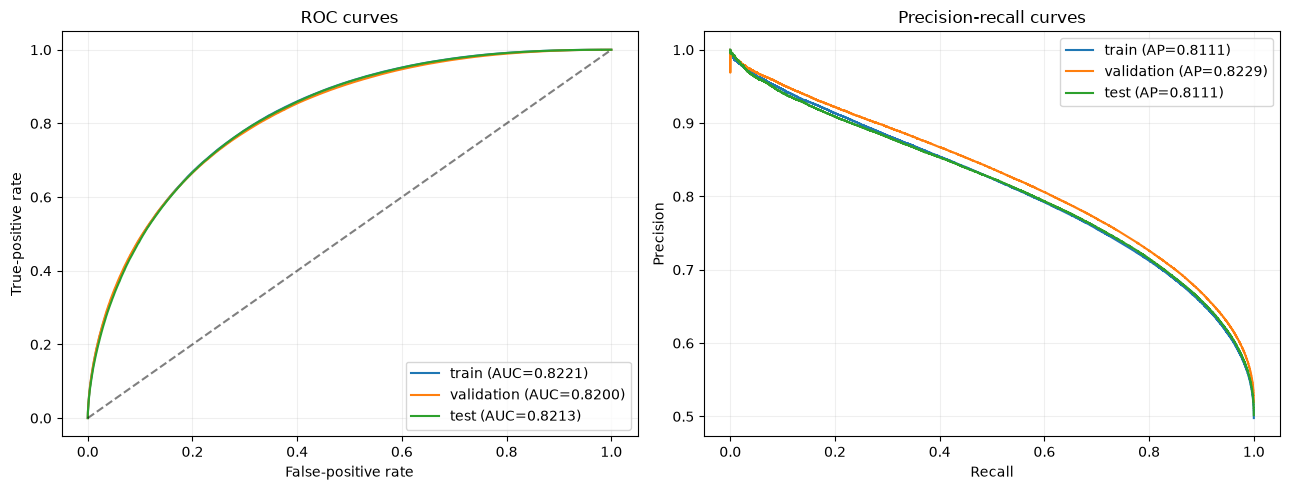

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split_name, (y_curve, p_curve) in curve_samples.items():
    fpr, tpr, _ = roc_curve(y_curve, p_curve)
    precision, recall, _ = precision_recall_curve(y_curve, p_curve)
    axes[0].plot(fpr, tpr, label=f"{split_name} (AUC={results['metrics'][split_name]['ROC-AUC']:.4f})")
    axes[1].plot(recall, precision, label=f"{split_name} (AP={results['metrics'][split_name]['PR-AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set(xlabel='False-positive rate', ylabel='True-positive rate', title='ROC curves')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-recall curves')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Score distributions

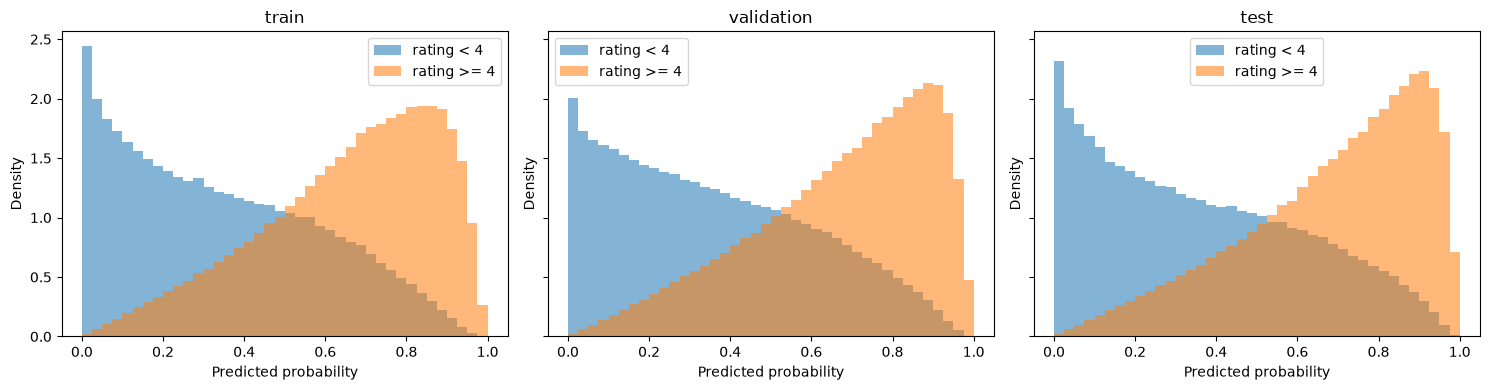

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)
for ax, (split_name, (y_curve, p_curve)) in zip(axes, curve_samples.items()):
    ax.hist(p_curve[y_curve == 0], bins=bins, density=True, alpha=0.55, label='rating < 4')
    ax.hist(p_curve[y_curve == 1], bins=bins, density=True, alpha=0.55, label='rating >= 4')
    ax.set(title=split_name, xlabel='Predicted probability', ylabel='Density')
    ax.legend()
plt.tight_layout()
plt.show()

## Observed high-rating prevalence by test-score ventile

The complete out-of-time test set is sorted into 20 approximately equal-sized groups based on predicted probability. Ventile 1 contains the lowest scores and ventile 20 the highest. A useful ranking model should generally show higher observed prevalence of `rating >= 4` in the later ventiles. Minor local deviations can still occur because the chart summarizes observed outcomes rather than imposing monotonicity.

,ventile,rows,score_min,score_mean,score_max,high_rating_rate_pct
0,1,42339,0.0003,0.0220,0.0460,1.70%
1,2,42339,0.0460,0.0727,0.0999,6.41%
2,3,42338,0.0999,0.1285,0.1579,12.25%
3,4,42339,0.1579,0.1875,0.2173,17.81%
4,5,42339,0.2173,0.2468,0.2763,23.99%
5,6,42339,0.2763,0.3055,0.3346,29.25%
6,7,42338,0.3346,0.3635,0.3919,34.99%
7,8,42339,0.3919,0.4196,0.4470,40.22%
8,9,42338,0.4470,0.4734,0.4997,44.69%
9,10,42339,0.4997,0.5251,0.5503,50.13%


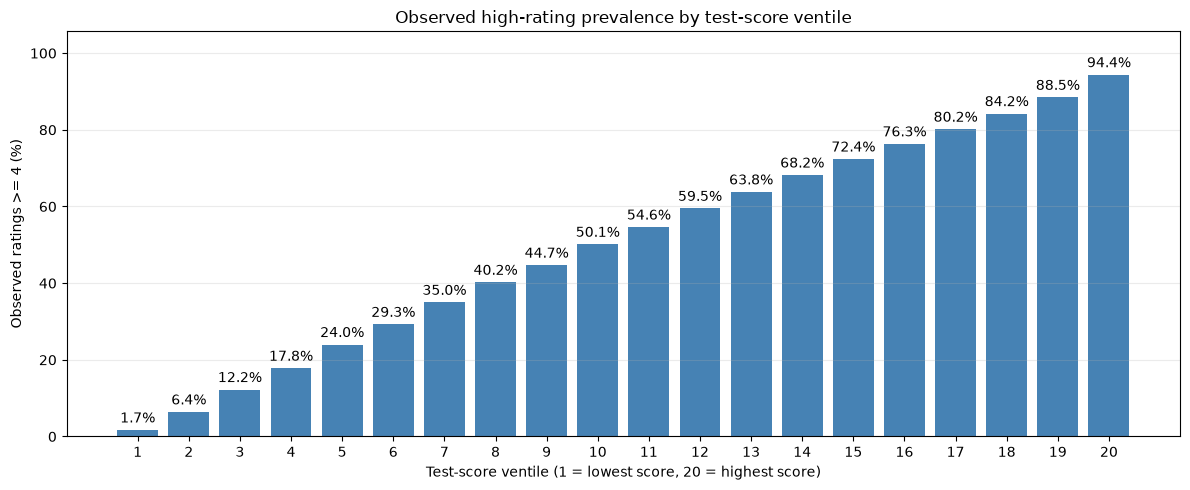

Saved: docs/whitepaper/figures/test_score_ventile_prevalence.png
Observed decreases between adjacent ventiles: 0


In [14]:
test_x, test_y, _ = load_split(
    prd_config.FEATURE_ARTIFACT_PATH,
    ratings,
    'test',
    prd_config.PRD_FEATURES,
)
test_score = model.predict_proba(test_x)[:, 1]
del test_x

test_ventiles = pd.DataFrame({'target': test_y, 'score': test_score})
test_ventiles['ventile'] = (
    pd.qcut(test_ventiles['score'], q=20, labels=False, duplicates='drop') + 1
)
ventile_summary = (
    test_ventiles.groupby('ventile', observed=True)
    .agg(
        rows=('target', 'size'),
        score_min=('score', 'min'),
        score_mean=('score', 'mean'),
        score_max=('score', 'max'),
        high_rating_rate=('target', 'mean'),
    )
    .reset_index()
)
ventile_summary['ventile'] = ventile_summary['ventile'].astype(int)
ventile_summary['high_rating_rate_pct'] = 100 * ventile_summary['high_rating_rate']

display(
    ventile_summary[
        ['ventile', 'rows', 'score_min', 'score_mean', 'score_max', 'high_rating_rate_pct']
    ].style.format(
        {
            'score_min': '{:.4f}',
            'score_mean': '{:.4f}',
            'score_max': '{:.4f}',
            'high_rating_rate_pct': '{:.2f}%',
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    ventile_summary['ventile'],
    ventile_summary['high_rating_rate_pct'],
    color='steelblue',
)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in ventile_summary['high_rating_rate_pct']], padding=3)
ax.set(
    xlabel='Test-score ventile (1 = lowest score, 20 = highest score)',
    ylabel='Observed ratings >= 4 (%)',
    title='Observed high-rating prevalence by test-score ventile',
)
ax.set_xticks(ventile_summary['ventile'])
ax.set_ylim(bottom=0, top=ventile_summary['high_rating_rate_pct'].max() * 1.12)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
ventile_figure_path = ROOT / 'docs/whitepaper/figures/test_score_ventile_prevalence.png'
ventile_figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ventile_figure_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', ventile_figure_path.relative_to(ROOT))

declines = int(ventile_summary['high_rating_rate'].diff().lt(0).sum())
print(f'Observed decreases between adjacent ventiles: {declines}')
if len(ventile_summary) < 20:
    print(
        f'Only {len(ventile_summary)} distinct quantile buckets were created '
        'because one or more score boundaries were tied.'
    )

## Test threshold performance by ventile cutoff

Each row uses the right boundary of one score ventile as a candidate decision threshold. An observation is alerted when `score >= score_cutoff`. Rows are ordered from ventile 1 to ventile 20, so the alert becomes progressively more selective. Metrics are calculated on the complete out-of-time test set.

In [15]:
test_target = test_ventiles['target'].to_numpy(dtype=bool, copy=False)
test_probability = test_ventiles['score'].to_numpy(copy=False)
threshold_rows = []

for bucket in ventile_summary.itertuples(index=False):
    score_cutoff = float(bucket.score_max)
    alerted = test_probability >= score_cutoff
    true_positives = int(np.count_nonzero(alerted & test_target))
    false_positives = int(np.count_nonzero(alerted & ~test_target))
    false_negatives = int(np.count_nonzero(~alerted & test_target))
    alerted_rows = true_positives + false_positives
    precision = true_positives / alerted_rows if alerted_rows else np.nan
    recall = true_positives / (true_positives + false_negatives)
    f1_score = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else np.nan
    )
    threshold_rows.append(
        {
            'ventile': int(bucket.ventile),
            'score_cutoff': score_cutoff,
            'alerted_rows': alerted_rows,
            'alert_rate': alerted.mean(),
            'true_positives': true_positives,
            'false_positives': false_positives,
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
        }
    )

threshold_performance = pd.DataFrame(threshold_rows)
display(
    threshold_performance.style.format(
        {
            'score_cutoff': '{:.6f}',
            'alerted_rows': '{:,}',
            'alert_rate': '{:.2%}',
            'true_positives': '{:,}',
            'false_positives': '{:,}',
            'precision': '{:.4f}',
            'recall': '{:.4f}',
            'f1_score': '{:.4f}',
        }
    )
)

latex_rows = []
for row in threshold_performance.itertuples(index=False):
    values = [
        str(row.ventile),
        f'{row.score_cutoff:.6f}',
        f'{row.alerted_rows:,}',
        f'{100 * row.alert_rate:.2f}\\%',
        f'{row.true_positives:,}',
        f'{row.false_positives:,}',
        f'{row.precision:.4f}',
        f'{row.recall:.4f}',
        f'{row.f1_score:.4f}',
    ]
    latex_rows.append(' & '.join(values) + r' \\')

threshold_table_lines = [
    r'\begin{table}[htbp]',
    r'\centering\scriptsize',
    r'\resizebox{\textwidth}{!}{%',
    r'\begin{tabular}{@{}rrrrrrrrr@{}}',
    r'\toprule',
    r'Ventile & Score cutoff & Alerted rows & Alert rate & TP & FP & Precision & Recall & F1 \\',
    r'\midrule',
    *latex_rows,
    r'\bottomrule',
    r'\end{tabular}%',
    r'}',
    r'\caption{Test-set classification performance when the right boundary of each score ventile is used as the alert threshold. An observation is alerted when its score is greater than or equal to the cutoff.}',
    r'\label{tab:ventile-threshold-performance}',
    r'\end{table}',
]
threshold_table_path = ROOT / 'docs/whitepaper/tables/threshold_performance.tex'
threshold_table_path.parent.mkdir(parents=True, exist_ok=True)
threshold_table_path.write_text('\n'.join(threshold_table_lines) + '\n')
print('Saved:', threshold_table_path.relative_to(ROOT))

,ventile,score_cutoff,alerted_rows,alert_rate,true_positives,false_positives,precision,recall,f1_score
0,1,0.046020,"804,436",95.00%,"424,130","380,306",0.5272,0.9983,0.6900
1,2,0.099916,"762,097",90.00%,"421,419","340,678",0.5530,0.9919,0.7101
2,3,0.157891,"719,759",85.00%,"416,233","303,526",0.5783,0.9797,0.7273
3,4,0.217347,"677,420",80.00%,"408,693","268,727",0.6033,0.9620,0.7415
4,5,0.276274,"635,081",75.00%,"398,535","236,546",0.6275,0.9381,0.7520
5,6,0.334639,"592,743",70.00%,"386,150","206,593",0.6515,0.9089,0.7589
6,7,0.391923,"550,404",65.00%,"371,338","179,066",0.6747,0.8740,0.7615
7,8,0.446961,"508,065",60.00%,"354,309","153,756",0.6974,0.8340,0.7596
8,9,0.499661,"465,727",55.00%,"335,389","130,338",0.7201,0.7894,0.7532
9,10,0.550300,"423,388",50.00%,"314,165","109,223",0.7420,0.7395,0.7407


Saved: docs/whitepaper/tables/threshold_performance.tex


## Test calibration

Reliability curve from the equal-width probability bins already stored in the PRD results payload.

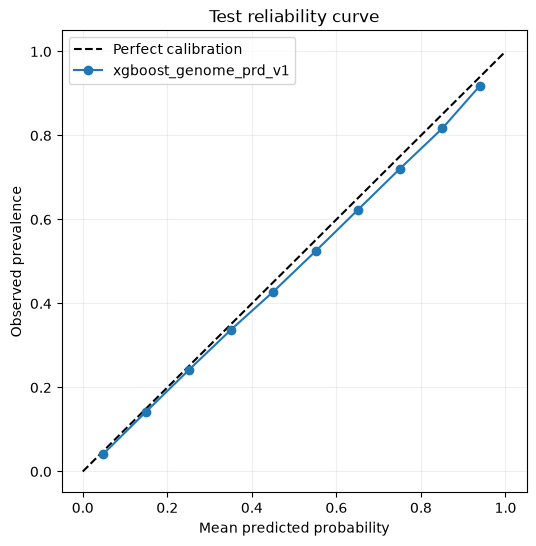

Test Brier score: 0.17279574275016785
Test ECE (10 uniform bins): 0.020751323726255304


In [16]:
calibration = pd.DataFrame(results['test_calibration_bins']).T
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(
    calibration['average_prediction'],
    calibration['observed_prevalence'],
    marker='o',
    label=prd_config.PRD_MODEL_NAME,
)
ax.set(
    xlabel='Mean predicted probability',
    ylabel='Observed prevalence',
    title='Test reliability curve',
)
ax.grid(alpha=0.2)
ax.legend()
plt.show()
print('Test Brier score:', results['metrics']['test']['Brier'])
print('Test ECE (10 uniform bins):', results['test_calibration_ece_10_uniform_bins'])

## Gain feature importance

,gain
feature,
genome_preference_margin,8876.809570
movie_rating_avg_60d,4828.744629
user_mean_rating,3779.002197
user_target_genre_mean_rating,2970.803955
movie_mean_rating,2650.219727
movie_rating_avg_30d,775.225708
genome_nearest_liked_similarity,698.636597
genome_top5_liked_similarity,498.597595
user_rating_count,496.552338


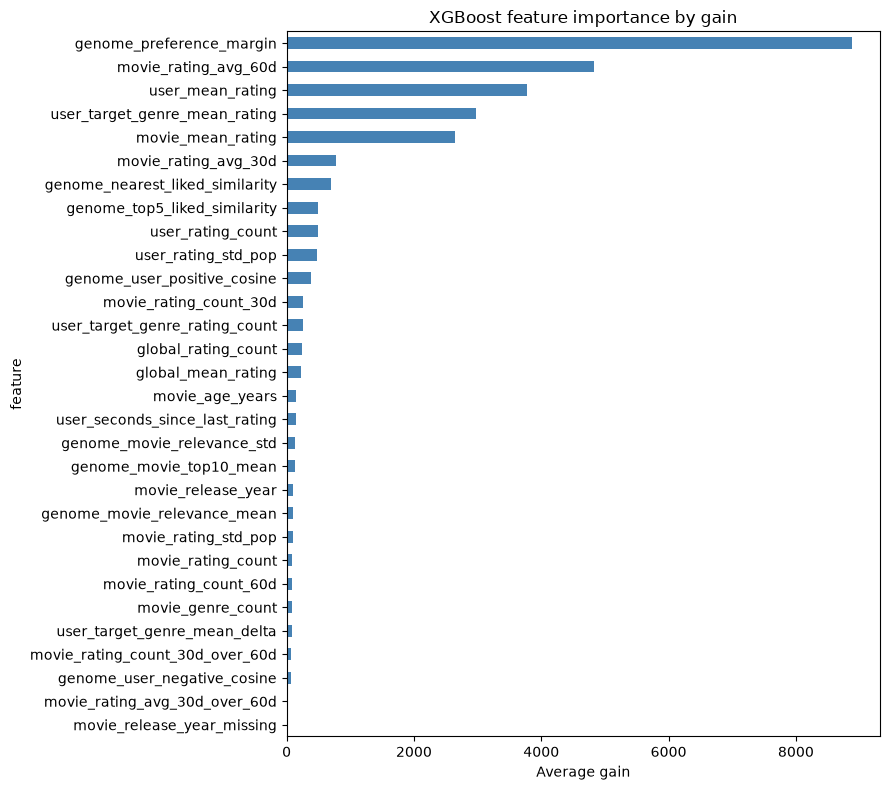

In [17]:
importance = (
    pd.DataFrame(results['gain_importance'])
    .set_index('feature')['gain']
    .sort_values(ascending=True)
)
display(importance.sort_values(ascending=False).to_frame())
ax = importance.plot.barh(
    figsize=(9, 8),
    color='steelblue',
    title='XGBoost feature importance by gain',
)
ax.set_xlabel('Average gain')
plt.tight_layout()
plt.show()

## Test-quarter metric trajectories

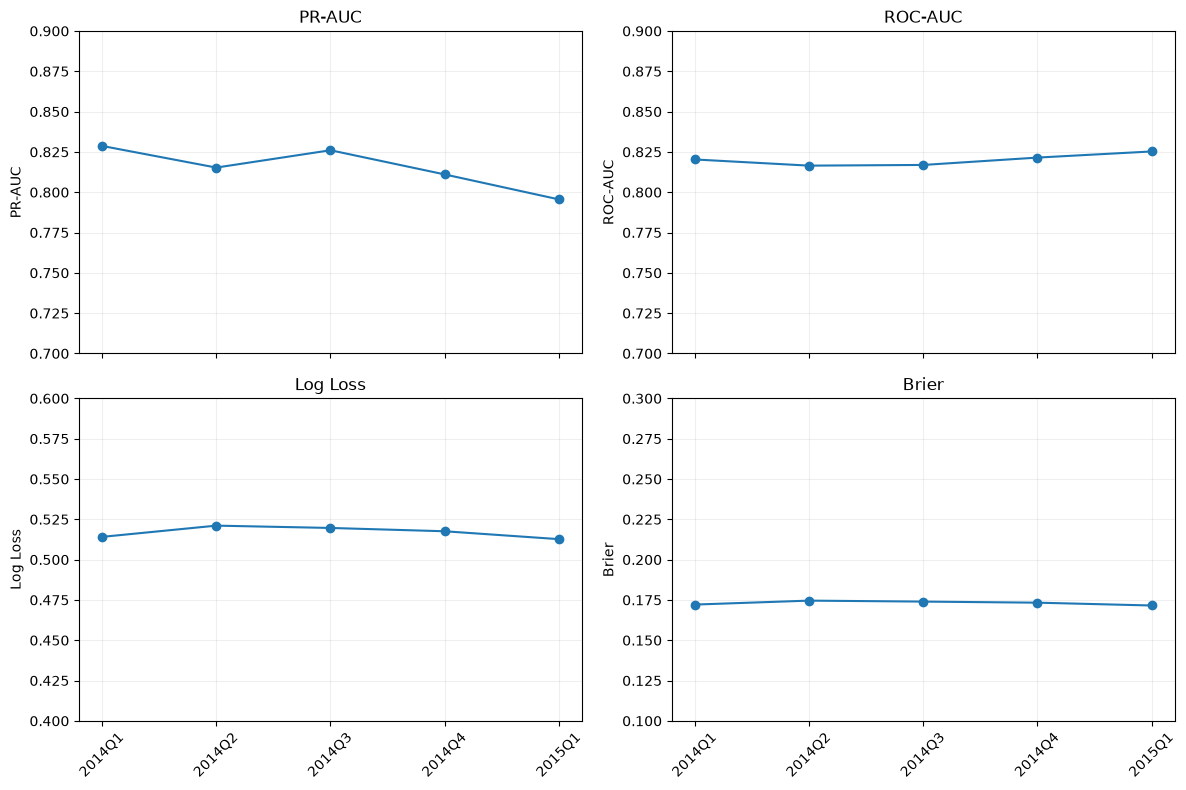

In [18]:
quarter_table = pd.DataFrame(results['test_quarter_metrics']).T.loc[
    list(prd_config.PRD_TEST_QUARTERS),
    ['PR-AUC', 'ROC-AUC', 'Log Loss', 'Brier'],
]
ym_lims = {
    'PR-AUC': (0.7, 0.9),
    'ROC-AUC': (0.7, 0.9),
    'Log Loss': (0.4, 0.6),
    'Brier': (0.1, 0.3),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.ravel(), quarter_table.columns):
    ax.plot(quarter_table.index, quarter_table[metric], marker='o')
    ax.set(title=metric, ylabel=metric, ylim=ym_lims[metric])
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Save the compact canonical PRD results artifact

In [19]:
write_json(prd_config.PRD_RESULTS_PATH, results)
print('Saved:', prd_config.PRD_RESULTS_PATH.relative_to(ROOT))

Saved: models/prd/xgboost_genome_prd_v1.results.json
